# Module 03 - Mô hình hóa và tầng quyết định

**Câu hỏi.** Trước khi giao, có thể dự báo đơn nào nguy cơ trễ để ưu
tiên theo dõi/điều phối không, và mô hình nào đáng tin nhất?

**Phương pháp.** Supervised learning theo đúng kỷ luật chống rò rỉ:

1. *Fit* preprocessing + model **chỉ trên train**.
2. *Chọn* mô hình trên **dev** theo F2 (ưu tiên không bỏ sót đơn trễ).
3. *Kiểm tra độ ổn định* bằng cross-validation trên train.
4. *Stress test* bằng 100 lần chia lại train/dev để xem điểm cao có
   ổn định hay chỉ may mắn.
5. *Khóa* mô hình rồi **báo test một lần**, kèm khoảng tin cậy bootstrap.

**Quyết định đầu ra.** Một mô hình khóa + xác suất trễ để tầng DSS biến
thành Risk Score/Priority.

> Lưu ý đọc kết quả: dữ liệu là synthetic gần tất định (xem Module 06),
> nên điểm số rất cao phản ánh độ dễ của dữ liệu, **không** phải năng
> lực dự báo thực tế. Giá trị học thuật nằm ở *quy trình* và *cách đọc*.

> **Đối tượng & cách đọc.** Notebook cho **người mới** trong nhóm. Lời
> giải thích bằng tiếng Việt; thuật ngữ tiếng Anh (F2, MCC, bootstrap…)
> được định nghĩa ở mục **"0. Định nghĩa"** và đầy đủ trong
> `docs/GLOSSARY.md`. Mỗi mục theo mạch *mục tiêu → phân tích → insight*;
> mỗi bảng/biểu đồ có **một dòng đọc-hiểu ngay bên dưới**.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
from IPython.display import Image
from pizza_dss.config import ACTIVE_FEATURE_COLUMNS, COMPACT_FEATURE_COLUMNS, FEATURE_COLUMNS, TARGET_COLUMN
from pizza_dss.data_loader import load_processed_splits, validate_feature_contract
from pizza_dss.decision_rules import get_dss_decision
from pizza_dss.modeling import (
    bootstrap_test_metrics,
    compare_feature_sets,
    compare_models,
    cross_validate_models,
    evaluate_baselines,
    load_best_model,
    metric_row,
    predict_delay_probability,
    train_and_evaluate,
)

**Khoá artifact chuẩn.** Cell dưới chạy `train_and_evaluate()` để sinh
model khóa + các hình đánh giá (so sánh model, confusion matrix, ROC,
hệ số, PR-curve) dùng chung cho notebook, slide và báo cáo.

In [2]:
_ = train_and_evaluate()

## 0. Định nghĩa các metric (đọc trước khi xem bảng)

**Vì sao bước này?**
- Làm gì: Chọn F2 Score làm metric chính để đánh giá và so sánh mô hình, kết hợp cùng Balanced Accuracy và MCC. Không dùng mỗi Accuracy.
- Vì sao: 
  - Lớp "trễ" là thiểu số (~21%). Accuracy dễ bị "ảo" (đoán toàn không trễ cũng được 79%).
  - Trong bài toán này, bỏ sót một đơn bị trễ (False Negative - FN) gây thiệt hại lớn (khách hàng không được báo trước, nhà hàng phải đền tiền/coupon) so với việc báo trễ nhầm (False Positive - FP, chỉ tốn công theo dõi). Metric **F2** ưu tiên Recall (bắt lỗi) gấp đôi Precision (chính xác), do đó phản ánh đúng trọng tâm vận hành.
- Kỹ thuật: Threshold optimization, F-beta score (beta=2).
- Bằng chứng dẫn tới: Tỷ lệ trễ thấp (~21%) và yêu cầu từ mô hình kinh doanh (giảm tối đa False Negative).

Lớp "trễ" là thiểu số (~21%), nên **không dùng Accuracy một mình**.

- **Accuracy**: tỷ lệ dự đoán đúng trên tổng. Dễ bị lớp đa số (on-time)
  đánh lừa.
- **Balanced Accuracy**: trung bình của Recall hai lớp; công bằng với
  lớp thiểu số.
- **Precision** = TP/(TP+FP): trong các đơn bị *cảnh báo trễ*, bao nhiêu
  % thực sự trễ. Cao = ít báo động giả.
- **Recall** (Sensitivity) = TP/(TP+FN): trong các đơn *thực sự trễ*,
  bắt được bao nhiêu %. Cao = ít bỏ sót.
- **F1** = trung bình điều hòa của Precision và Recall (cân bằng).
- **F2** = F-beta với beta=2, **ưu tiên Recall gấp đôi Precision**. Chọn
  vì bỏ sót đơn trễ (FN) tốn chi phí vận hành hơn cảnh báo dư (FP).
- **MCC** (Matthews): tương quan giữa dự đoán và thực tế trên cả 4 ô của
  confusion matrix; nằm trong [-1, 1], 0 = đoán mò. Bền với mất cân bằng.
- **ROC-AUC**: khả năng xếp hạng (đơn trễ có xác suất cao hơn đơn không
  trễ); 0.5 = ngẫu nhiên, 1.0 = hoàn hảo.
- **TN/FP/FN/TP**: bốn ô confusion matrix (đúng-âm/dương-giả/âm-giả/đúng-dương).

## 1. Split và feature contract

In [3]:
validate_feature_contract()
train_df, dev_df, test_df = load_processed_splits()
pd.DataFrame([
    {"split": "train", "rows": len(train_df), "delayed": int(train_df[TARGET_COLUMN].sum()),
     "delayed_rate": round(train_df[TARGET_COLUMN].mean(), 4)},
    {"split": "dev", "rows": len(dev_df), "delayed": int(dev_df[TARGET_COLUMN].sum()),
     "delayed_rate": round(dev_df[TARGET_COLUMN].mean(), 4)},
    {"split": "test", "rows": len(test_df), "delayed": int(test_df[TARGET_COLUMN].sum()),
     "delayed_rate": round(test_df[TARGET_COLUMN].mean(), 4)},
])

,split,rows,delayed,delayed_rate
0,train,602,126,0.2093
1,dev,201,42,0.2090
2,test,201,42,0.2090


**Insight.** `validate_feature_contract()` chạy không lỗi nghĩa là không
feature nào nằm trong danh sách rò rỉ. Tỷ lệ trễ ~21% được giữ đều ở cả
ba split (stratified). Test chỉ có ~42 đơn trễ — đây là lý do ở mục 5 ta
phải kèm khoảng tin cậy bootstrap thay vì tin tuyệt đối vào điểm số.

## 2. Baseline bắt buộc trên dev

**Vì sao bước này?**
- Làm gì: Tạo 2 mô hình "ngốc" (Baseline) là "Always on-time" (đoán toàn đúng giờ) và "Always delayed" (đoán toàn trễ) để làm mốc so sánh.
- Vì sao: Để biết các mô hình ML phức tạp có thực sự học được gì không. Nếu mô hình ML không vượt được F2 và MCC của Baseline, nghĩa là nó vô dụng.
- Kỹ thuật: Majority Class Baseline.
- Bằng chứng dẫn tới: Always-on-time có Accuracy cao (~0.79) nhưng F2 = 0, cho thấy Accuracy không phản ánh đúng mục tiêu bắt lỗi.

In [4]:
evaluate_baselines(dev_df[TARGET_COLUMN]).round(4)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp
0,Always on-time,0.791,0.5,0.000,0.0,0.0000,0.0000,0.0,NaN,159,0,42,0
1,Always delayed,0.209,0.5,0.209,1.0,0.3457,0.5691,0.0,NaN,0,159,0,42


**Định nghĩa.** *Always on-time* = đoán mọi đơn không trễ; *Always
delayed* = đoán mọi đơn trễ. Đây là mốc tối thiểu mọi mô hình phải vượt.

**Insight.** Always-on-time đạt Accuracy ~0.79 nhưng **F2 = 0, MCC = 0**
(không bắt được đơn trễ nào) — minh chứng vì sao Accuracy gây hiểu lầm.
Always-delayed có Recall = 1 nhưng Precision thấp. Mô hình tốt phải vượt
cả hai về F2 và MCC.

## 3. So sánh feature set: full vs compact

**Vì sao bước này?**
- Làm gì: Đóng gói các bước tiền xử lý (StandardScaler cho biến số thực, OneHot cho phân loại) vào Pipeline và chạy mô hình so sánh trên tập `full` và tập `compact`. Cài đặt `class_weight="balanced"` cho mô hình.
- Vì sao: 
  - Pipeline (có StandardScaler/OneHot) đảm bảo transform chỉ học trên tập Train, tránh rò rỉ sang tập Dev/Test.
  - `class_weight="balanced"` giúp phạt nặng khi đoán sai lớp "trễ" (do nó chiếm tỷ lệ ít), ép mô hình chú ý đến chúng.
  - So sánh Feature set giúp chứng minh bằng thực nghiệm: bỏ bớt các cột dư thừa không làm giảm hiệu suất, lại giúp mô hình chạy nhanh, bớt overfitting hơn.
- Kỹ thuật: scikit-learn Pipeline, Feature Selection, Cost-sensitive learning (`class_weight`).
- Bằng chứng dẫn tới: Mô hình chạy với tập `compact` (bỏ đi các cột redundant như estimated_duration) có F2 ngang bằng tập `full` (nhiều cột).

In [5]:
{
    "full_pre_dispatch": FEATURE_COLUMNS,
    "compact_nonredundant": COMPACT_FEATURE_COLUMNS,
    "active_for_locked_model": ACTIVE_FEATURE_COLUMNS,
}

{'full_pre_dispatch': ['toppings_count',
  'distance_km',
  'topping_density',
  'estimated_duration_min',
  'pizza_complexity',
  'traffic_impact',
  'order_hour',
  'restaurant_name',
  'location',
  'pizza_size',
  'pizza_type',
  'traffic_level',
  'payment_method',
  'is_peak_hour',
  'is_weekend',
  'order_month',
  'payment_category'],
 'compact_nonredundant': ['toppings_count',
  'distance_km',
  'order_hour',
  'pizza_size_score',
  'restaurant_name',
  'location',
  'pizza_type',
  'traffic_level',
  'payment_category',
  'is_peak_hour',
  'is_weekend',
  'order_month'],
 'active_for_locked_model': ['toppings_count',
  'distance_km',
  'order_hour',
  'pizza_size_score',
  'restaurant_name',
  'location',
  'pizza_type',
  'traffic_level',
  'payment_category',
  'is_peak_hour',
  'is_weekend',
  'order_month']}

In [6]:
compare_feature_sets(train_df, dev_df).round(4)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp,feature_count,note
1,compact_nonredundant,0.9701,0.9636,0.9091,0.9524,0.9302,0.9434,0.9117,0.9942,155,4,2,40,12,Drops formula-derived columns and uses pizza_s...
0,full_pre_dispatch,0.9701,0.9549,0.9286,0.9286,0.9286,0.9286,0.9097,0.9904,156,3,3,39,17,Includes engineered deterministic columns for ...


**Insight.** Compact bỏ các cột tất định (`estimated_duration_min`,
`topping_density`, `pizza_complexity`, `traffic_impact`) và mã hóa size
bằng `pizza_size_score` (1-4). Dev F2 của compact ngang hoặc nhỉnh hơn
full dù **ít feature hơn** → bằng chứng các cột công thức là *redundant*,
không thêm thông tin. Vì vậy mô hình khóa dùng compact (đơn giản, ít
nguy cơ overfit).

## 3b. Vì sao chọn đúng sáu classifier này?

Sáu mô hình phủ các họ thuật toán trong học phần, từ tuyến tính tới
ensemble, để so sánh công bằng.

In [7]:
pd.DataFrame([
    {"model": "Logistic Regression", "ho": "Tuyến tính/xác suất",
     "gia_dinh": "Log-odds tuyến tính theo feature", "vi_sao": "Baseline mạnh, hệ số diễn giải được"},
    {"model": "Decision Tree", "ho": "Cây",
     "gia_dinh": "Chia ngưỡng đệ quy, phi tuyến", "vi_sao": "Dễ giải thích luật if-then"},
    {"model": "Naive Bayes", "ho": "Xác suất sinh",
     "gia_dinh": "Feature độc lập có điều kiện, Gaussian", "vi_sao": "Nhanh, mốc tham chiếu"},
    {"model": "k-NN", "ho": "Dựa lân cận",
     "gia_dinh": "Đơn giống nhau thì cùng nhãn", "vi_sao": "Phi tham số, nhạy với scaling"},
    {"model": "SVM (RBF)", "ho": "Biên cực đại",
     "gia_dinh": "Tách lớp bằng kernel phi tuyến", "vi_sao": "Mạnh khi biên phức tạp"},
    {"model": "Random Forest", "ho": "Ensemble bagging",
     "gia_dinh": "Trung bình nhiều cây ngẫu nhiên", "vi_sao": "Giảm phương sai, robust"},
])

,model,ho,gia_dinh,vi_sao
0,Logistic Regression,Tuyến tính/xác suất,Log-odds tuyến tính theo feature,"Baseline mạnh, hệ số diễn giải được"
1,Decision Tree,Cây,"Chia ngưỡng đệ quy, phi tuyến",Dễ giải thích luật if-then
2,Naive Bayes,Xác suất sinh,"Feature độc lập có điều kiện, Gaussian","Nhanh, mốc tham chiếu"
3,k-NN,Dựa lân cận,Đơn giống nhau thì cùng nhãn,"Phi tham số, nhạy với scaling"
4,SVM (RBF),Biên cực đại,Tách lớp bằng kernel phi tuyến,Mạnh khi biên phức tạp
5,Random Forest,Ensemble bagging,Trung bình nhiều cây ngẫu nhiên,"Giảm phương sai, robust"


**Insight.** Mỗi họ có điểm mạnh khác nhau; so sánh trên cùng feature
set và cùng metric giúp lựa chọn dựa trên bằng chứng, không cảm tính.

## 4. So sánh sáu classifier trên dev (một lần split)

In [8]:
dev_metrics, fitted = compare_models(train_df, dev_df)
dev_metrics.round(4)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp
0,Logistic Regression,0.9701,0.9636,0.9091,0.9524,0.9302,0.9434,0.9117,0.9942,155,4,2,40
4,SVM,0.9701,0.9461,0.9500,0.9048,0.9268,0.9135,0.9085,0.9874,157,2,4,38
1,Decision Tree,0.9502,0.9335,0.8636,0.9048,0.8837,0.8962,0.8525,0.9488,153,6,4,38
5,Random Forest,0.9652,0.9254,0.9730,0.8571,0.9114,0.8780,0.8926,0.9780,158,1,6,36
3,k-NN,0.9353,0.8540,0.9677,0.7143,0.8219,0.7538,0.7970,0.9666,158,1,12,30
2,Naive Bayes,0.6368,0.7179,0.3495,0.8571,0.4966,0.6642,0.3544,0.7844,92,67,6,36


**Cách đọc.** Bảng đã sắp theo F2 giảm dần (rồi Balanced Accuracy, MCC).
Cột tn/fp/fn/tp cho thấy cơ cấu lỗi của từng mô hình.

**Insight.** Logistic Regression đứng đầu F2/MCC; Naive Bayes có Recall
cao nhưng nhiều FP nên Precision và F2 thấp. Đây mới là **một lần** chia
dev nên cần kiểm tra độ ổn định ở mục 4b.

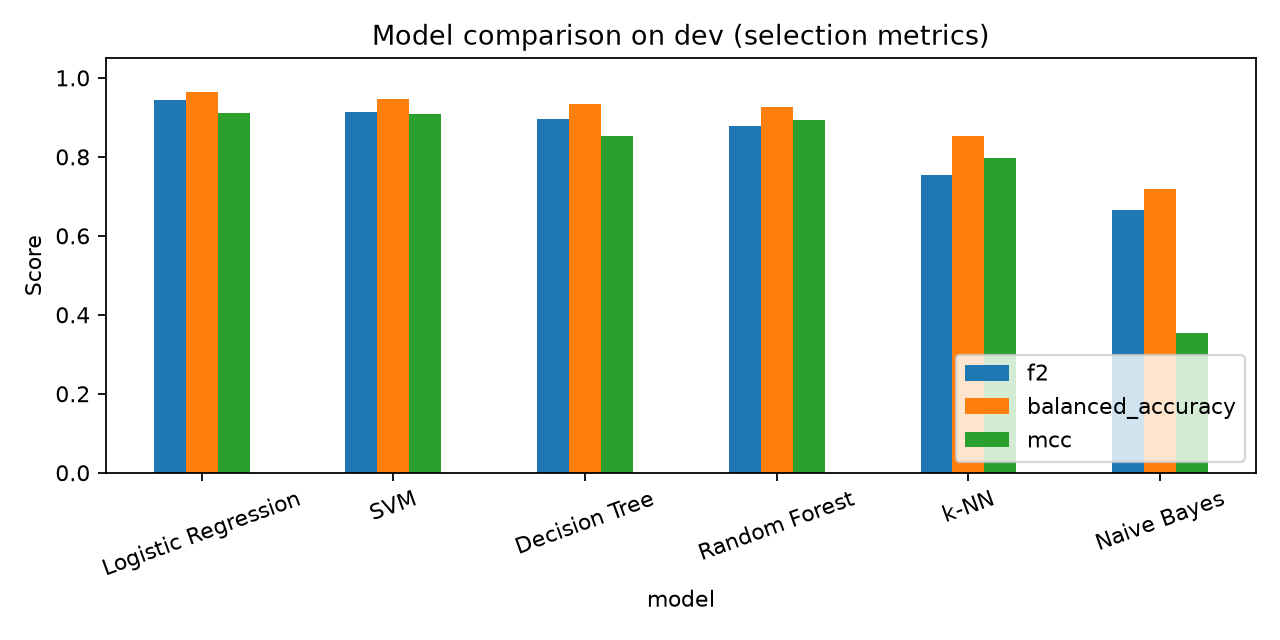

In [9]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "model_comparison.png"))

**Insight (hình).** Trực quan hóa khoảng cách F2/Balanced-Accuracy/MCC giữa các mô hình: nhóm tuyến tính/SVM/cây vượt trội, Naive Bayes tụt lại.

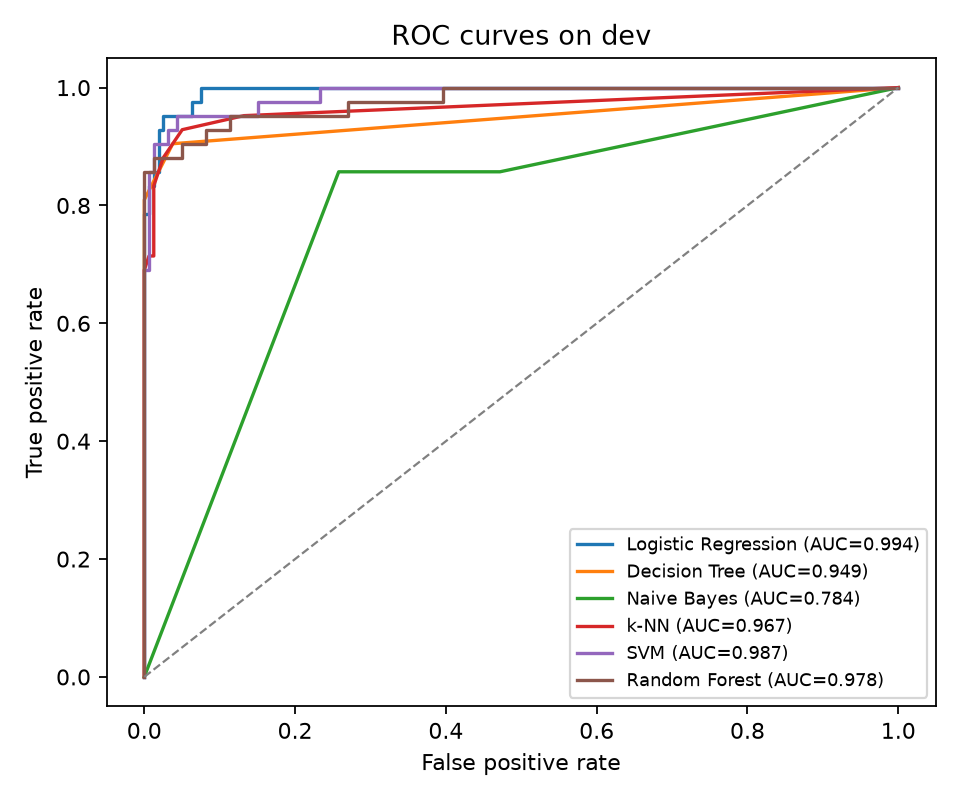

In [10]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "roc_curves.png"))

**Insight (hình).** ROC nằm sát góc trên-trái = tách lớp tốt; AUC trong chú thích xác nhận Logistic Regression và SVM xếp hạng rủi ro tốt nhất.

## 4b. Cross-validation trên train (kiểm tra độ ổn định)

**Vì sao bước này?**
- Làm gì: Chạy Cross-Validation (K-fold=5) trên tập Train cho tất cả các mô hình để xem hiệu suất trung bình và độ lệch chuẩn.
- Vì sao: Việc so sánh trên 1 tập Dev duy nhất (ở Bước 4) có thể bị "ăn may" do ngẫu nhiên khi chia data. CV 5-fold (chia train làm 5 phần, luân phiên test trên từng phần) đánh giá độ ổn định của thuật toán trên các tập dữ liệu khác nhau.
- Kỹ thuật: K-Fold Cross Validation.
- Bằng chứng dẫn tới: Standard Deviation (độ lệch chuẩn) của F2 và MCC sau CV ở Logistic Regression rất nhỏ, chứng minh tính ổn định cao.

**Định nghĩa.** Stratified k-fold: chia train thành k phần giữ nguyên tỷ
lệ trễ, lần lượt train trên k-1 phần và đánh giá trên phần còn lại. Báo
mean ± std để thấy mô hình *ổn định* hay *may rủi theo split*.

In [11]:
cross_validate_models(train_df, k=5).round(4)

,model,cv_folds,f2_mean,f2_std,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,roc_auc_mean,roc_auc_std
0,Decision Tree,5,0.9432,0.0216,0.9637,0.0130,0.9136,0.0182,0.9755,0.0168
1,Logistic Regression,5,0.9387,0.0323,0.9609,0.0204,0.9123,0.0390,0.9952,0.0041
2,SVM,5,0.9307,0.0373,0.9573,0.0226,0.9349,0.0258,0.9961,0.0053
3,Random Forest,5,0.9255,0.0323,0.9529,0.0198,0.9023,0.0327,0.9934,0.0046
4,k-NN,5,0.8226,0.1037,0.8948,0.0588,0.8556,0.0756,0.9931,0.0020
5,Naive Bayes,5,0.7192,0.0495,0.7717,0.0369,0.4443,0.0622,0.7783,0.0512


**Insight.** F2 trung bình 5-fold cao và **độ lệch chuẩn nhỏ** ở các mô
hình dẫn đầu → kết quả không phải nhờ một split may mắn. Logistic
Regression vừa cao vừa ổn định, củng cố lựa chọn làm mô hình khóa.

## 4c. 100-run stability audit (kiểm soát may mắn do chia split)

**Vì sao bước này?**
- Làm gì: Gộp train+dev, chia stratified lại 100 lần, mỗi lần fit Logistic Regression và đánh giá trên validation split mới. Test không tham gia.
- Vì sao: Cross-validation 5-fold vẫn chỉ là vài lần chia. Với dataset nhỏ và synthetic, cần kiểm tra thêm xem F2 cao có ổn định qua nhiều split hay chỉ do dev split ban đầu "đẹp".
- Kỹ thuật: Repeated stratified holdout, giữ threshold mặc định 0.5 và cấu hình LR đã khóa.
- Bằng chứng dẫn tới: `reports/metrics/model_stability_100runs.csv` và `model_stability_summary.json` cho thấy F2 mean≈0.9419, p05≈0.8892, p95≈0.9770 trên 100 lần; tức kết quả cao nhưng vẫn có biên dao động thật.

In [12]:
stability_summary = pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "model_stability_summary.csv")
stability_runs = pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "model_stability_100runs.csv")
display(stability_summary[stability_summary["metric"].isin(["f2", "mcc", "recall", "precision"])].round(4))
stability_runs[["f2", "mcc", "recall", "precision"]].describe(percentiles=[0.05, 0.5, 0.95]).round(4)

,metric,mean,std,min,p05,p50,p95,max
0,f2,0.9419,0.0279,0.8416,0.8892,0.9479,0.9770,0.9906
2,mcc,0.9161,0.0290,0.8495,0.8687,0.9207,0.9569,0.9849
3,recall,0.9481,0.0355,0.8095,0.8810,0.9524,1.0000,1.0000
4,precision,0.9206,0.0367,0.8200,0.8542,0.9259,0.9756,1.0000


,f2,mcc,recall,precision
count,100.0000,100.0000,100.0000,100.0000
mean,0.9419,0.9161,0.9481,0.9206
std,0.0280,0.0291,0.0357,0.0369
min,0.8416,0.8495,0.8095,0.8200
5%,0.8892,0.8687,0.8810,0.8542
50%,0.9479,0.9207,0.9524,0.9259
95%,0.9769,0.9569,1.0000,0.9756
max,0.9906,0.9849,1.0000,1.0000


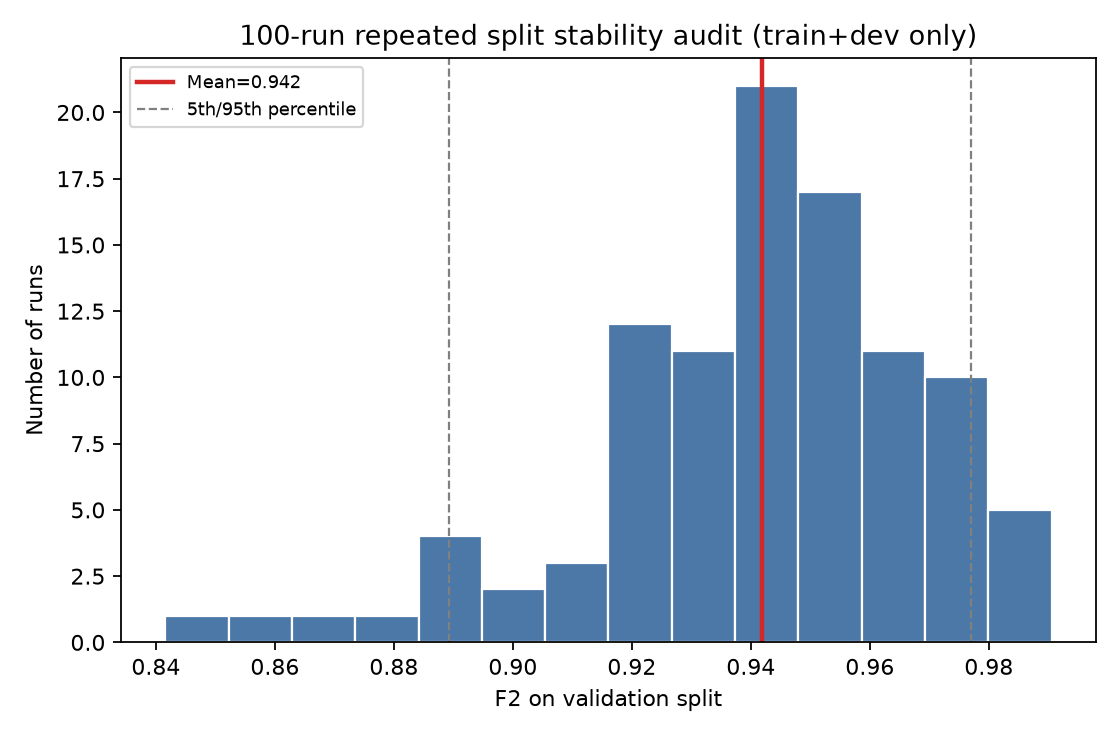

In [13]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "model_stability_f2_distribution.png"))

**Insight.** Phân phối F2 tập trung quanh ~0.94, nhưng đáy 5% vẫn xuống
khoảng 0.89 và min ~0.84. Kết luận đúng là: mô hình **ổn định trên dữ
liệu này**, nhưng không được nói "chắc chắn luôn đạt 0.95" vì split nhỏ
vẫn tạo dao động.

## 4d. Dò siêu tham số (tuning)

**Vì sao bước này?**
- Làm gì: Thử nghiệm nhiều giá trị khác nhau cho các tham số nội tại (hyperparameters) của Logistic Regression (vd: hệ số C).
- Vì sao: Để tìm ra cấu hình tốt nhất giúp mô hình học chính xác hơn trên dữ liệu. Ở đây tune `C` (inverse of regularization strength) để điều chỉnh mức độ phạt (phạt lớn = C nhỏ = chống overfit mạnh).
- Tại sao dùng CV trên Train, không dùng Test: Để ngăn **Leakage**; nếu ta nhìn điểm Test để chọn tham số, mô hình đã gián tiếp học lỏm tập Test và làm kết quả Test mất tính khách quan (Data Leakage qua Hyperparameters).
- Kỹ thuật: GridSearchCV + Stratified K-Fold CV (scoring=F2). Dải C được chọn log-scale (0.1, 0.3, 1, 3, 10) quét từ phạt mạnh đến yếu quanh giá trị mặc định là 1.0.
- Bằng chứng dẫn tới: Điểm Test không được dùng vào bất kỳ bước nào trong việc train hay chọn model/param. Scoring F2 thống nhất với tiêu chí vận hành đã định (chống False Negative).

In [14]:
tuning = pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "hyperparameter_tuning.csv")
default_vs_tuned = pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "default_vs_tuned_lr.csv")
display(tuning.round(4))
display(default_vs_tuned[[
    "model", "param_C", "cv_f2_mean", "cv_f2_std",
    "f2", "mcc", "delta_dev_f2_vs_default", "decision"
]].round(4))

,param_C,mean_test_f2,std_test_f2
0,0.3,0.9437,0.0375
1,3.0,0.9387,0.0323
2,1.0,0.9387,0.0323
3,0.1,0.9368,0.0429
4,10.0,0.9337,0.0333


,model,param_C,cv_f2_mean,cv_f2_std,f2,mcc,delta_dev_f2_vs_default,decision
0,default_lr,1.0,0.9387,0.0323,0.9434,0.9117,0.000,locked
1,tuned_lr,0.3,0.9437,0.0375,0.8894,0.8779,-0.054,not_locked


**Cách đọc & CAVEAT.** Bảng đầu là kết quả GridSearchCV trên train;
bảng thứ hai là kiểm tra default-vs-tuned trên dev trước khi khóa
model. Cột `decision` cho biết cấu hình nào được dùng làm model cuối.

Vì dữ liệu synthetic vốn có quy luật tất định gần hoàn hảo, tuning
thường không tạo bước nhảy lớn. Quy tắc khóa đã cố định trong code:
chỉ đổi sang tuned LR nếu dev F2 tăng ít nhất 0.01; nếu không, giữ
default để tránh phức tạp hóa không cần thiết.

**Vì sao chỉ fine-tune Logistic Regression, không tune 5 model còn lại?**
- Nguyên tắc "select-then-tune": quy trình chuẩn là CHỌN họ mô hình trước (qua so
  sánh + cross-validation), rồi mới tinh chỉnh siêu tham số cho HỌ THẮNG. LR thắng
  vòng chọn (dev F2 cao nhất, CV ổn định) nên chỉ LR cần tune. Tune cả 6 trước khi
  chọn là lãng phí và làm tăng nguy cơ overfit tập dev nhỏ (~42 đơn trễ) do so
  sánh nhiều lần.
- Dữ liệu synthetic gần tất định: tín hiệu tách lớp quá dễ (ROC-AUC ~0,99 ngay với
  tham số mặc định), nên tune BẤT KỲ model nào cũng gần như không đổi F2. Tune
  model khoá là đủ để minh hoạ kỹ thuật.
- LR được chọn vì hợp mục tiêu DSS: hệ số diễn giải được (nuôi trực tiếp giải
  thích Risk Score), huấn luyện nhanh, xác suất ổn định.
- Lý do riêng từng model không tune thêm:
  • Naive Bayes: gần như không có siêu tham số (chỉ var_smoothing), lại thua rõ.
  • Decision Tree: thua LR; tune cây đơn dễ overfit, và đã có Random Forest là bản
    ensemble của nó. Cây giữ lại chỉ để so sánh tính diễn giải.
  • k-NN: thua; nhạy với không gian nhiều chiều (one-hot location 84 mức), tune k
    không sửa được hạn chế gốc.
  • SVM (RBF): F2 sát LR (á quân) — nếu LR không được chọn thì SVM là ứng viên
    tune tiếp theo; nhưng SVM kém diễn giải hơn và probability cần CV nội bộ
    (chậm, đã deprecated), nên không ưu tiên.
  • Random Forest: recall/F2 thấp hơn LR, nhiều siêu tham số + chậm hơn; dữ liệu
    đơn giản không cần độ phức tạp ensemble.
- Kết luận: tune LR là đủ và hợp lý; KHÔNG cần tune các model khác.

## 4e. F-beta threshold analysis (ngưỡng vận hành)

**Vì sao bước này?**
- Làm gì: Quét nhiều ngưỡng xác suất trên dev và tính F1/F2/F3, Precision, Recall, FP/FN cho từng ngưỡng.
- Vì sao: `predict_proba` chỉ cho xác suất; quyết định cảnh báo trễ cần một ngưỡng. Ngưỡng 0.5 là mặc định kỹ thuật, không tự động tối ưu cho vận hành.
- Kỹ thuật: Threshold optimization trên dev, so sánh F-beta với beta=1/2/3 để thấy cách đổi trọng số Precision-Recall.
- Bằng chứng dẫn tới: `reports/metrics/fbeta_threshold_analysis.csv` cho thấy F2/F3 tối ưu trên dev tại threshold≈0.157 với Recall=1.0, FN=0 nhưng FP=12; `fbeta_threshold_policy_transfer.csv` cho thấy khi chuyển threshold này sang test thì FN=0 nhưng FP tăng lên 22 và F2 giảm so với default.

In [15]:
threshold_audit = pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "fbeta_threshold_analysis.csv")
threshold_transfer = pd.read_csv(PROJECT_ROOT / "reports" / "metrics" / "fbeta_threshold_policy_transfer.csv")
best_thresholds = threshold_audit[
    threshold_audit["is_best_for_beta"].astype(str).str.lower().eq("true")
][[
    "beta", "threshold", "precision", "recall", "fbeta_score",
    "accuracy", "mcc", "fp", "fn", "tp", "operating_goal"
]]
display(best_thresholds.round(4))
display(threshold_transfer[
    (threshold_transfer["split"] == "test") &
    (threshold_transfer["model"].isin(["default_0_5", "dev_best_f2"]))
][[
    "model", "threshold", "precision", "recall", "f1", "f2", "mcc", "fp", "fn", "tp"
]].round(4))

,beta,threshold,precision,recall,fbeta_score,accuracy,mcc,fp,fn,tp,operating_goal
184,1.0,0.4400,0.9091,0.9524,0.9302,0.9701,0.9117,4,2,40,balance_precision_recall
432,2.0,0.1569,0.7778,1.0000,0.9459,0.9403,0.8480,12,0,42,coursework_policy_prioritize_recall
717,3.0,0.1569,0.7778,1.0000,0.9722,0.9403,0.8480,12,0,42,high_recall_stress_test


,model,threshold,precision,recall,f1,f2,mcc,fp,fn,tp
4,default_0_5,0.5000,0.8542,0.9762,0.9111,0.9491,0.8889,7,1,41
6,dev_best_f2,0.1569,0.6562,1.0000,0.7925,0.9052,0.7520,22,0,42


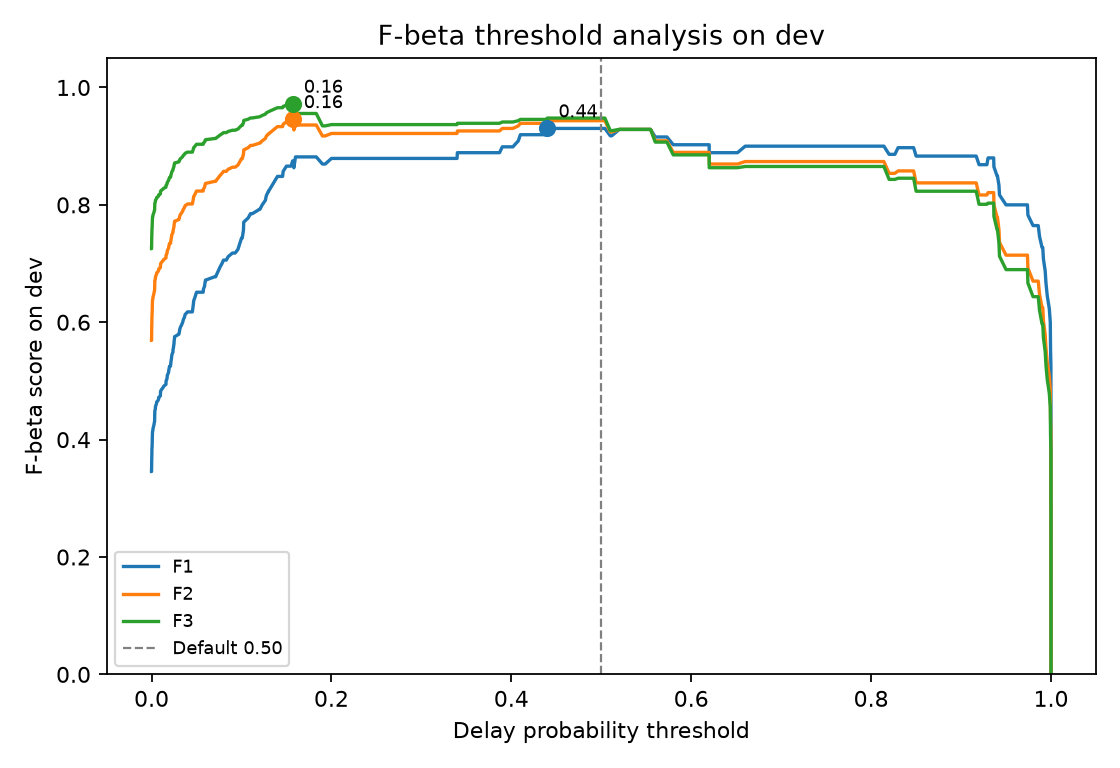

In [16]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "fbeta_threshold_curve.png"))

**Insight.** Tối ưu threshold theo dev **không tự động tốt hơn trên
test**: ngưỡng F2 ~0.157 bắt hết đơn trễ trên test (FN=0) nhưng FP tăng
từ 7 lên 22 nên F2 test giảm. Vì vậy báo cáo chính giữ threshold 0.5
cho metric test, còn dashboard trình bày threshold như **policy có thể
điều chỉnh** nếu quản lý muốn đổi giữa "ít bỏ sót" và "ít cảnh báo dư".

## 5. Test sau khi khóa mô hình (báo một lần)

In [17]:
best_name = "Logistic Regression"
best_model = load_best_model()
prob = predict_delay_probability(best_model, test_df)
pred = prob >= 0.5
pd.DataFrame([metric_row(best_name, test_df[TARGET_COLUMN], pred, prob)]).round(4)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp
0,Logistic Regression,0.9602,0.9661,0.8542,0.9762,0.9111,0.9491,0.8889,0.9961,152,7,1,41


**Insight.** Mô hình khóa vượt xa cả hai baseline trên test. Recall cao = ít bỏ sót đơn trễ, đúng mục tiêu vận hành.

**Số này tốt hay xấu? (cho người mới).** Đừng nhìn một số đơn lẻ — hãy
so với baseline ở mục 6:
- **Recall ~0,98**: bắt được gần hết đơn trễ (điều quan trọng nhất) —
  baseline "luôn đúng giờ" chỉ được 0.
- **F2 ~0,95 / MCC ~0,89**: điểm tổng cao, vượt xa baseline ⇒ mô hình
  thực sự có ích trên dữ liệu này.
- **Nhưng:** dữ liệu là synthetic gần tất định + test nhỏ (~201 đơn),
  nên điểm cao **không** đồng nghĩa "đoán giỏi ngoài đời". Vì vậy mục
  5b báo kèm **khoảng tin cậy (CI)**. (Chi tiết: `START_HERE.md` §3.)

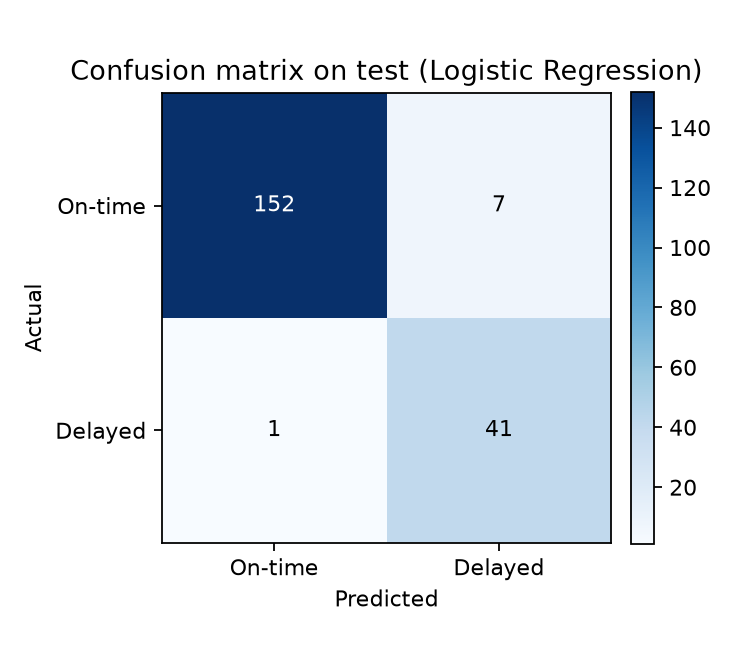

In [18]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "confusion_matrix_test.png"))

**Insight (hình).** Đọc theo chi phí vận hành: ô **FN** (đơn trễ bị bỏ
sót) là tốn nhất vì khách không được cảnh báo; ô **FP** chỉ tốn công theo
dõi dư. Mô hình giữ FN rất thấp — phù hợp việc tối ưu F2.

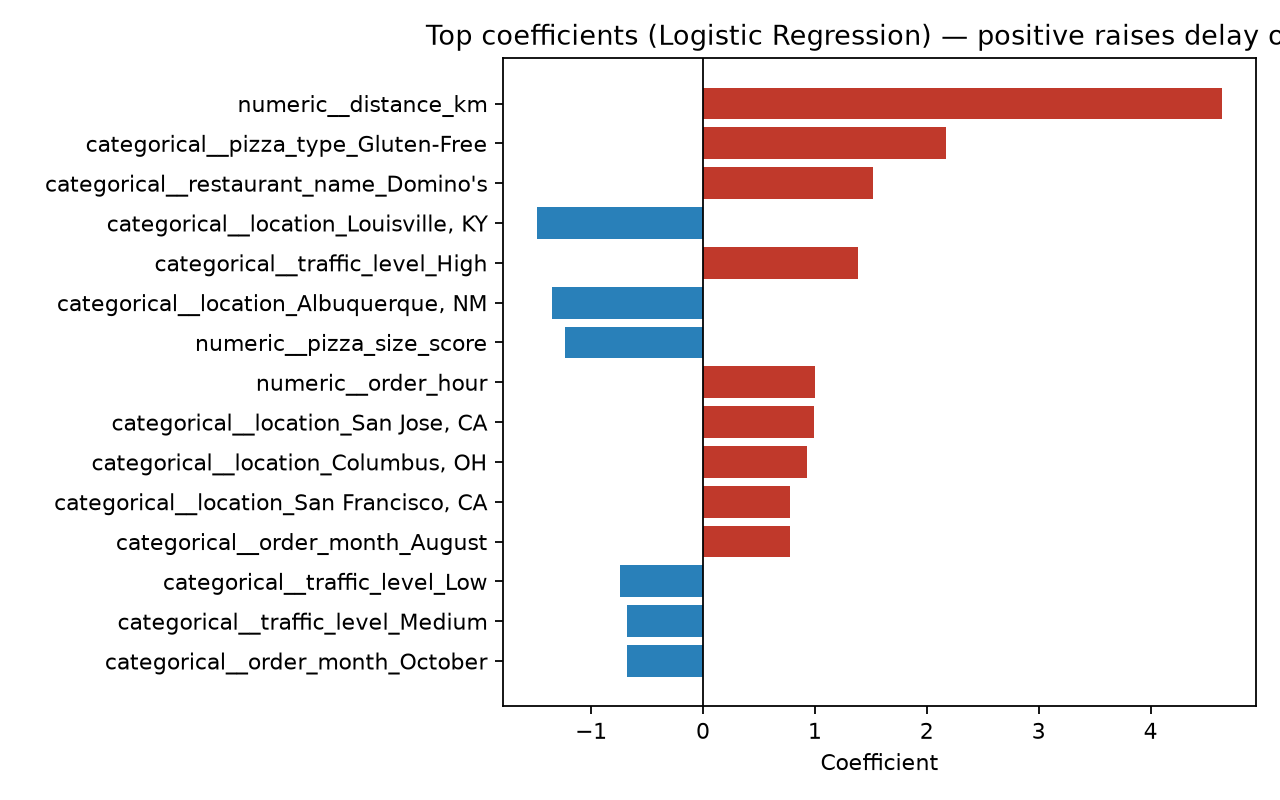

In [19]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "model_coefficients.png"))

**Insight (hình).** Hệ số dương lớn ở distance/traffic cao = các yếu tố này tăng odds trễ, khớp EDA và công thức Risk Score (Module 04).

## 5b. Khoảng tin cậy bootstrap cho metric test

**Vì sao bước này?**
- Làm gì: Tính toán Khoảng tin cậy (Confidence Interval - CI) cho các điểm đánh giá của mô hình bằng phương pháp Bootstrap (lấy mẫu có hoàn lại từ tập Test).
- Vì sao: Tập Test rất nhỏ (chỉ ~201 dòng, trong đó có khoảng 42 dòng nhãn bị trễ). Sự vắng mặt hay đoán sai của 1-2 đơn có thể làm thay đổi hoàn toàn điểm F2. Bootstrap CI báo cáo trung thực biên độ dao động, cho thấy mô hình tốt cỡ nào trong kịch bản tệ nhất.
- Kỹ thuật: Bootstrap Resampling (n_boot=2000).
- Bằng chứng dẫn tới: Dataset nhỏ gây biến động mạnh (tỷ lệ trễ test set nhỏ). Bảng kết quả bootstrap CI chỉ ra khoảng dưới và trên của F2 rất rộng.

**Định nghĩa.** Lấy mẫu lại có hoàn lại từ 201 đơn test nhiều lần, tính
metric mỗi lần, lấy phân vị 2.5%-97.5% làm khoảng tin cậy 95%. Cần thiết
vì test chỉ ~42 đơn trễ, một vài FN có thể làm điểm dao động mạnh.

In [20]:
bootstrap_test_metrics(best_model, test_df, n_boot=2000)

,metric,point_estimate,ci_low_2_5,ci_high_97_5,bootstrap_std,n_boot
0,f2,0.9491,0.8955,0.9859,0.0229,2000
1,balanced_accuracy,0.9661,0.9329,0.9904,0.0145,2000
2,mcc,0.8889,0.8083,0.9583,0.0381,2000
3,recall,0.9762,0.9189,1.0000,0.0235,2000


**Insight.** Khoảng tin cậy của F2/MCC khá **rộng** (do n nhỏ), nên phải
trình bày điểm test kèm CI, **không** tuyên bố một con số tuyệt đối. Đây
là cách đọc trung thực với cỡ mẫu nhỏ.

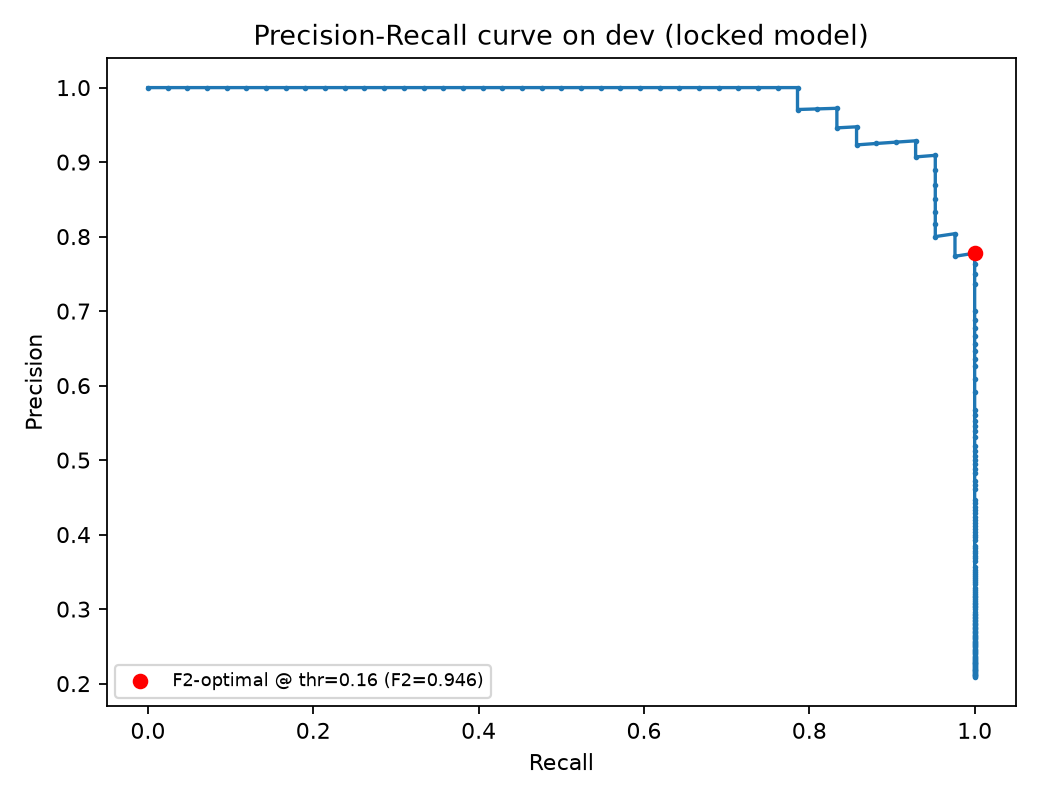

In [21]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "pr_curve.png"))

**Insight (hình).** Đường Precision-Recall và điểm F2-optimal cho thấy vì
sao ngưỡng vận hành có thể lệch khỏi 0.5: muốn tối đa F2 (ưu tiên Recall),
ngưỡng tối ưu thường thấp hơn, đánh đổi thêm vài FP để bắt thêm đơn trễ.

## 6. Baseline test (đối chứng)

In [22]:
evaluate_baselines(test_df[TARGET_COLUMN]).round(4)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp
0,Always on-time,0.791,0.5,0.000,0.0,0.0000,0.0000,0.0,NaN,159,0,42,0
1,Always delayed,0.209,0.5,0.209,1.0,0.3457,0.5691,0.0,NaN,0,159,0,42


**Insight.** Đặt cạnh mục 5 để thấy mức cải thiện thực của mô hình so với đoán-một-lớp; luôn báo baseline cạnh kết quả cuối.

## 7. Ví dụ tầng DSS trên hàng đợi test

In [23]:
model = load_best_model()
probabilities = predict_delay_probability(model, test_df)
rows = []
for i, (_, order) in enumerate(test_df.head(10).iterrows()):
    decision = get_dss_decision(order, probabilities[i])
    rows.append({
        "order_id": order["order_id"],
        "traffic_level": order["traffic_level"],
        "distance_km": order["distance_km"],
        "true_is_delayed": order["is_delayed"],
        **decision,
    })
pd.DataFrame(rows).sort_values("delay_risk_score", ascending=False)

,order_id,traffic_level,distance_km,true_is_delayed,delayed_probability,delay_risk_score,priority,recommended_action
0,ORD002,High,5.0,False,0.1790,44.0,Medium,Monitor driver assignment and traffic conditio...
2,ORD009,High,5.0,False,0.0376,38.7,Medium,Monitor driver assignment and traffic conditio...
1,ORD006,High,3.0,False,0.0231,32.5,Low,Keep in normal queue but watch traffic because...
7,ORD028,High,3.5,False,0.0101,32.4,Low,Keep in normal queue but watch traffic because...
9,ORD036,Medium,4.5,False,0.0116,28.2,Low,Keep in normal delivery queue.
8,ORD033,Medium,3.5,False,0.0037,26.0,Low,Keep in normal delivery queue.
3,ORD014,Low,4.0,False,0.0018,24.7,Low,Keep in normal delivery queue.
5,ORD018,Medium,3.5,False,0.0017,24.7,Low,Keep in normal delivery queue.
6,ORD027,Medium,2.0,False,0.0005,22.8,Low,Keep in normal delivery queue.
4,ORD017,Low,2.0,False,0.0002,15.6,Low,Keep in normal delivery queue.


**Insight.** Xác suất trễ được biến thành `delay_risk_score`, `priority`
và `recommended_action`. Risk Score là **chính sách minh bạch**, không
phải nhãn học từ dữ liệu — chi tiết công thức ở Module 04.

## 8. Insight → quyết định mô hình hóa

In [24]:
pd.DataFrame([
    {"cau_hoi": "Metric chọn mô hình?", "bang_chung": "Trễ là thiểu số ~21%; FN đắt hơn FP.",
     "quyet_dinh": "Chọn theo F2 trên dev, báo kèm Balanced Acc/MCC, không dùng Accuracy đơn lẻ."},
    {"cau_hoi": "Feature set nào?", "bang_chung": "Compact F2 >= full dù ít cột; cột công thức redundant.",
     "quyet_dinh": "Khóa mô hình trên compact (12 feature)."},
    {"cau_hoi": "Mô hình nào?", "bang_chung": "LogReg dẫn đầu F2/MCC, CV ổn định, hệ số diễn giải được.",
     "quyet_dinh": "Khóa Logistic Regression."},
    {"cau_hoi": "Điểm cao có ăn may không?", "bang_chung": "100-run train/dev stability: F2 mean≈0.9419, p05≈0.8892.",
     "quyet_dinh": "Báo ổn định tương đối, nhưng không overclaim vì split nhỏ và data synthetic."},
    {"cau_hoi": "Ngưỡng cảnh báo nào?", "bang_chung": "F2/F3 tối ưu dev ở threshold≈0.157; F1 tối ưu 0.44.",
     "quyet_dinh": "Giữ 0.5 cho model metric test, trình bày threshold như policy có thể đổi trong DSS."},
    {"cau_hoi": "Điểm test tin được không?", "bang_chung": "n=201 (~42 trễ); CI bootstrap rộng.",
     "quyet_dinh": "Báo test kèm CI; không overclaim; nêu rõ dữ liệu synthetic."},
])

,cau_hoi,bang_chung,quyet_dinh
0,Metric chọn mô hình?,Trễ là thiểu số ~21%; FN đắt hơn FP.,"Chọn theo F2 trên dev, báo kèm Balanced Acc/MC..."
1,Feature set nào?,Compact F2 >= full dù ít cột; cột công thức re...,Khóa mô hình trên compact (12 feature).
2,Mô hình nào?,"LogReg dẫn đầu F2/MCC, CV ổn định, hệ số diễn ...",Khóa Logistic Regression.
3,Điểm cao có ăn may không?,"100-run train/dev stability: F2 mean≈0.9419, p...","Báo ổn định tương đối, nhưng không overclaim v..."
4,Ngưỡng cảnh báo nào?,F2/F3 tối ưu dev ở threshold≈0.157; F1 tối ưu ...,"Giữ 0.5 cho model metric test, trình bày thres..."
5,Điểm test tin được không?,n=201 (~42 trễ); CI bootstrap rộng.,Báo test kèm CI; không overclaim; nêu rõ dữ li...
